# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [35]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Đào Anh Quân"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600028"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [37]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://roughly-come-alice-boston.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [3]:
display_student_header()

In [38]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 5 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 64.0% | Mem: 13.8/16.0GB | Power: 51W | Temp: 57°C
   GPU 1 [T4] 🔴 Util: 76.5% | Mem: 8.8/16.0GB | Power: 61W | Temp: 68°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 89.0% | Mem: 45.7/80.0GB | Power: 192W | Temp: 62°C
   GPU 1 [A100] 🔴 Util: 85.8% | Mem: 59.4/80.0GB | Power: 224W | Temp: 70°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 75.4% | Mem: 25.1/32.0GB | Power: 246W | Temp: 81°C
   GPU 1 [V100] 🟢 Util: 2.9% | Mem: 0.6/32.0GB | Power: 45W | Temp: 38°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 8.2% | Mem: 1.6/16.0GB | Power: 22W | Temp: 35°C
   GPU 1 [T4] 🟢 Util: 7.1% | Mem: 1.4/16.0GB | Power: 27W | Temp: 42°C

🖥️  node-04:
   GPU 0 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C
   GPU 1 [T4] 🟢 Util: 0.0% | Mem: 0.5/16.0GB | Power: 20W | Temp: 30°C


In [39]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          10
Busy GPUs:           5
Idle GPUs:           5
Avg Utilization:     40.9%
Memory Used:         157.4 GB
Memory Capacity:     320.0 GB
Total Power Draw:    908 W
Node Count:          5


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [40]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-03', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-03', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-04', 'gpu_id': 0}, {'node_id': 'node-04', 'gpu_id': 1}]

📊 Updated metrics:
   Busy GPUs: 10/10 | Utilization: 80.3%


In [41]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $2.5589
   Total Savings:  $2.7078
   Budget Used:    2.6%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [42]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.1982     43.4    % low
A100       $3.67       $2.1223     42.2    % medium
V100       $2.48       $1.6004     35.5    % medium


In [43]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [44]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 5

   ⚠️  Preempted:
      - spot-t4-002 (ran for 1s, 120s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0285
   On-demand equiv:  $0.0951
   Total saved:      $0.0665 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [45]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [46]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 80.3% > threshold 70.0%
   Current utilization: 80.3%
   Nodes: 5 → 6

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 66.9% | Nodes: 6→6
   Cycle 2: no_action    | Util: 66.9% | Nodes: 6→6
   Cycle 3: no_action    | Util: 66.9% | Nodes: 6→6
   Cycle 4: no_action    | Util: 66.9% | Nodes: 6→6
   Cycle 5: no_action    | Util: 66.9% | Nodes: 6→6


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [47]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 2: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 3: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 4: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%
   Snapshot 5: Total=$0.041944 | Idle=$0.001944 | Waste=4.6%


In [48]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          12.1%
   Total Idle Cost:        $0.046996
   Total Cost:             $0.401944
   Potential Monthly Save:  $1218.14
   Severity:               LOW


In [49]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [50]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 12 GPUs across 6 nodes
   Utilization: 66.9% | Busy: 10 | Idle: 2

💰 BILLING: $2.5589 / $100.00 budget
   Alert: OK | Savings: $2.7078

🎯 SPOT: Saved $0.0873 (70.0%)

🗑️  WASTE: 12.1% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

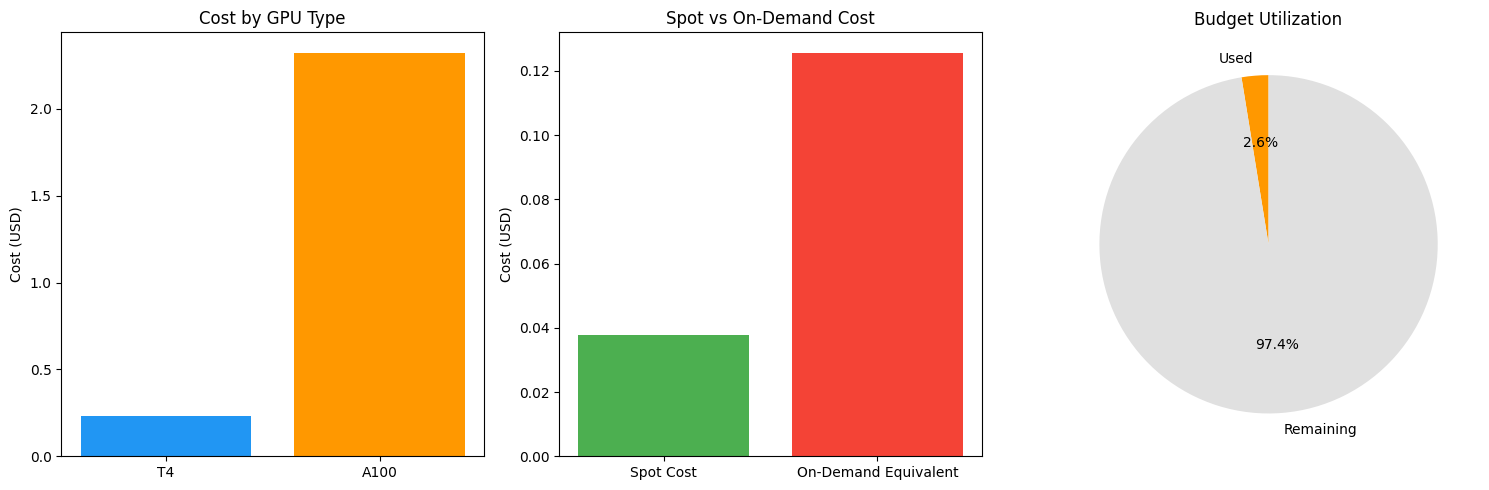

📊 Chart saved as finops_cost_breakdown.png


In [51]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


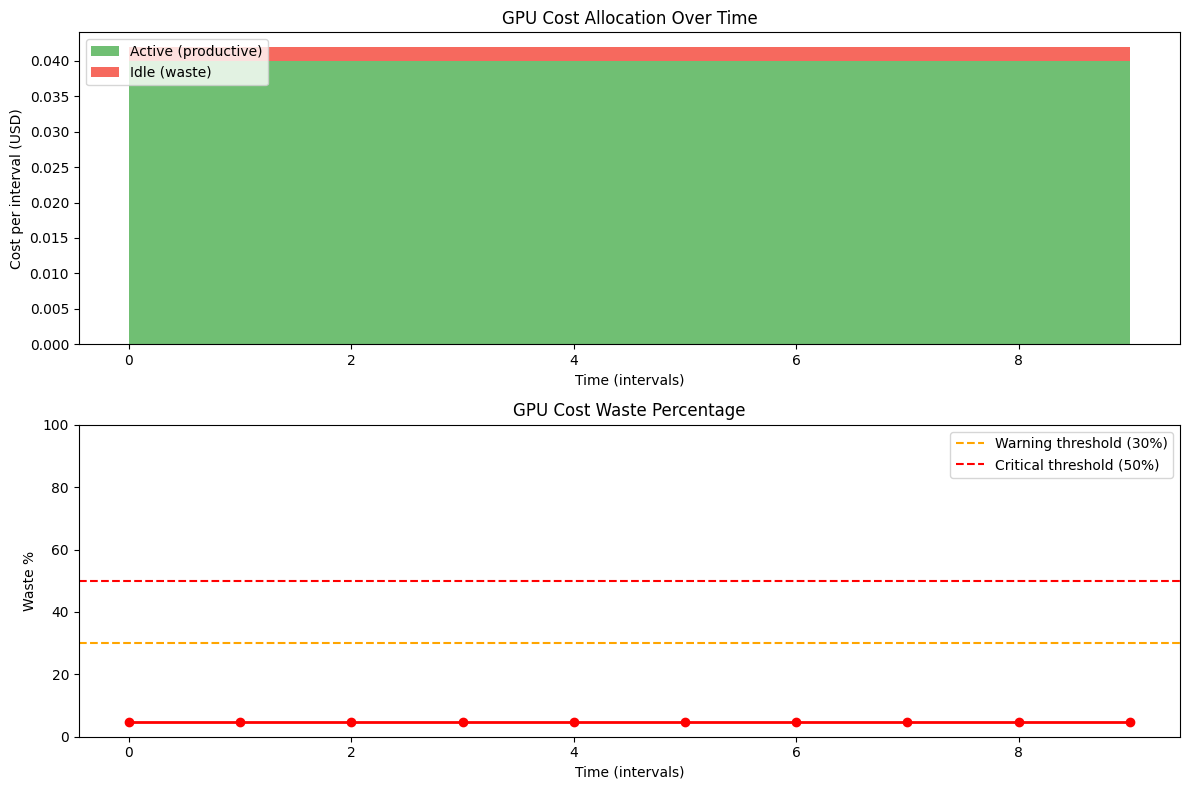

In [52]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [53]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 12 | Util: 66.9% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 77.7% | Busy: 12/12

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 77.7% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.043889
   Waste: 4.4%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0340 (70.0%)

7️⃣  Final billing:
   Total spend: $2.7280
   Total saved: $2.8302
   Budget: 2.7% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [54]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [55]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=1684/16106 MB
   Power: 32.3W
   Temp: 72C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 1684.209664
   mem_util_pct: 0.0
   power_watts: 32.261
   temp_c: 72.0

   Method: pynvml

Ready for training.


In [56]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [ ]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 2.1092 | Acc: 24.9% | Time: 45.9s | Samples: 40
   Epoch 2/3 | Loss: 1.4740 | Acc: 45.6% | Time: 43.9s | Samples: 40


In [58]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

   Epoch 1/3 | Loss: 1.9529 | Acc: 29.1% | Time: 19.9s | Samples: 40
   Epoch 2/3 | Loss: 1.4388 | Acc: 46.8% | Time: 19.9s | Samples: 40
   Epoch 3/3 | Loss: 1.1298 | Acc: 59.2% | Time: 19.9s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      59.8s
   Peak memory:     0.60 GB
   Avg GPU util:    89.8%
   Avg power:       64.3W
   Avg temperature: 76.6C
   Max GPU util:    93.0%
   Estimated cost:  $0.005815


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                134.9           59.8            2.25x faster
Peak Memory (GB)          0.97            0.60            0.36 GB saved
Cost (USD)                $0.013112       $0.005815       $0.007297 saved
Cost Saving %             ---             ---             55.7%
Avg GPU Util %            94.9            89.8           
Avg Power (W)             66.9            64.3           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$3.73 -> SAVE $4.67
   1 week training: FP32=$58.80 vs AMP=$26.08 -> SAVE $32.72
   1 month training: FP32=$252.00 vs AMP=$111.76 -> SAVE $140.24


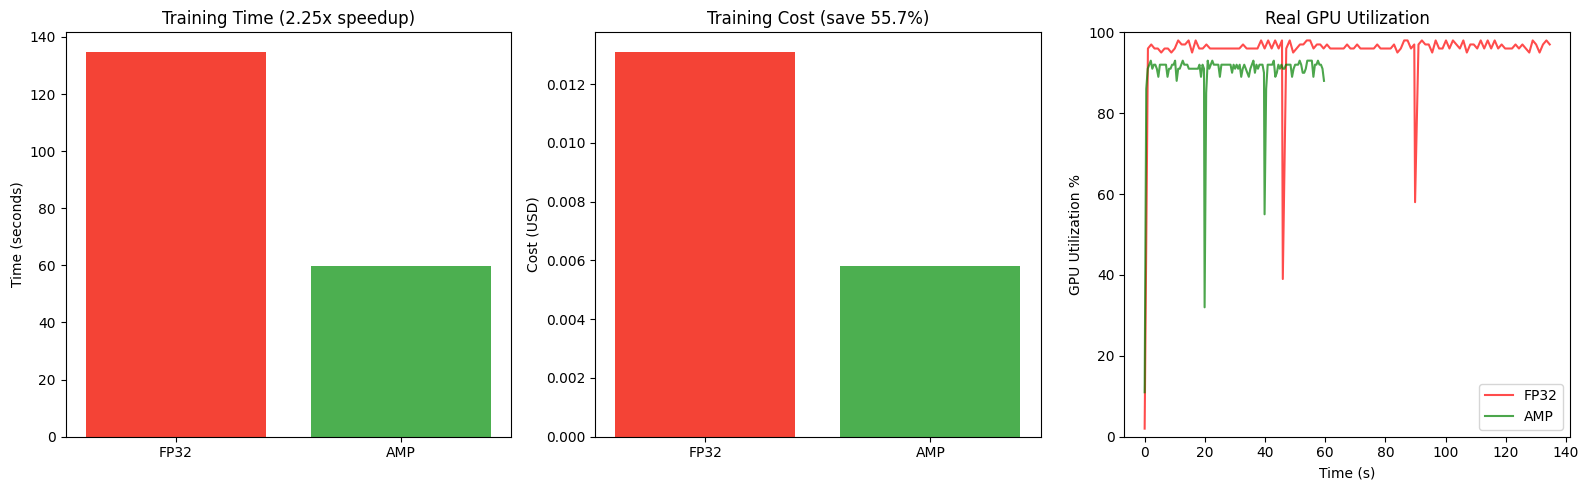

In [59]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.013100 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.004100

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.014800
   Total Savings:   $0.004100
   Workloads:       2

   Cost snapshot taken: waste=20.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $2.7280
   Total Savings:        $2.8302
   Budget Utilization:   2.7%
   Alert:                OK


Real GPU Telemetry During Training


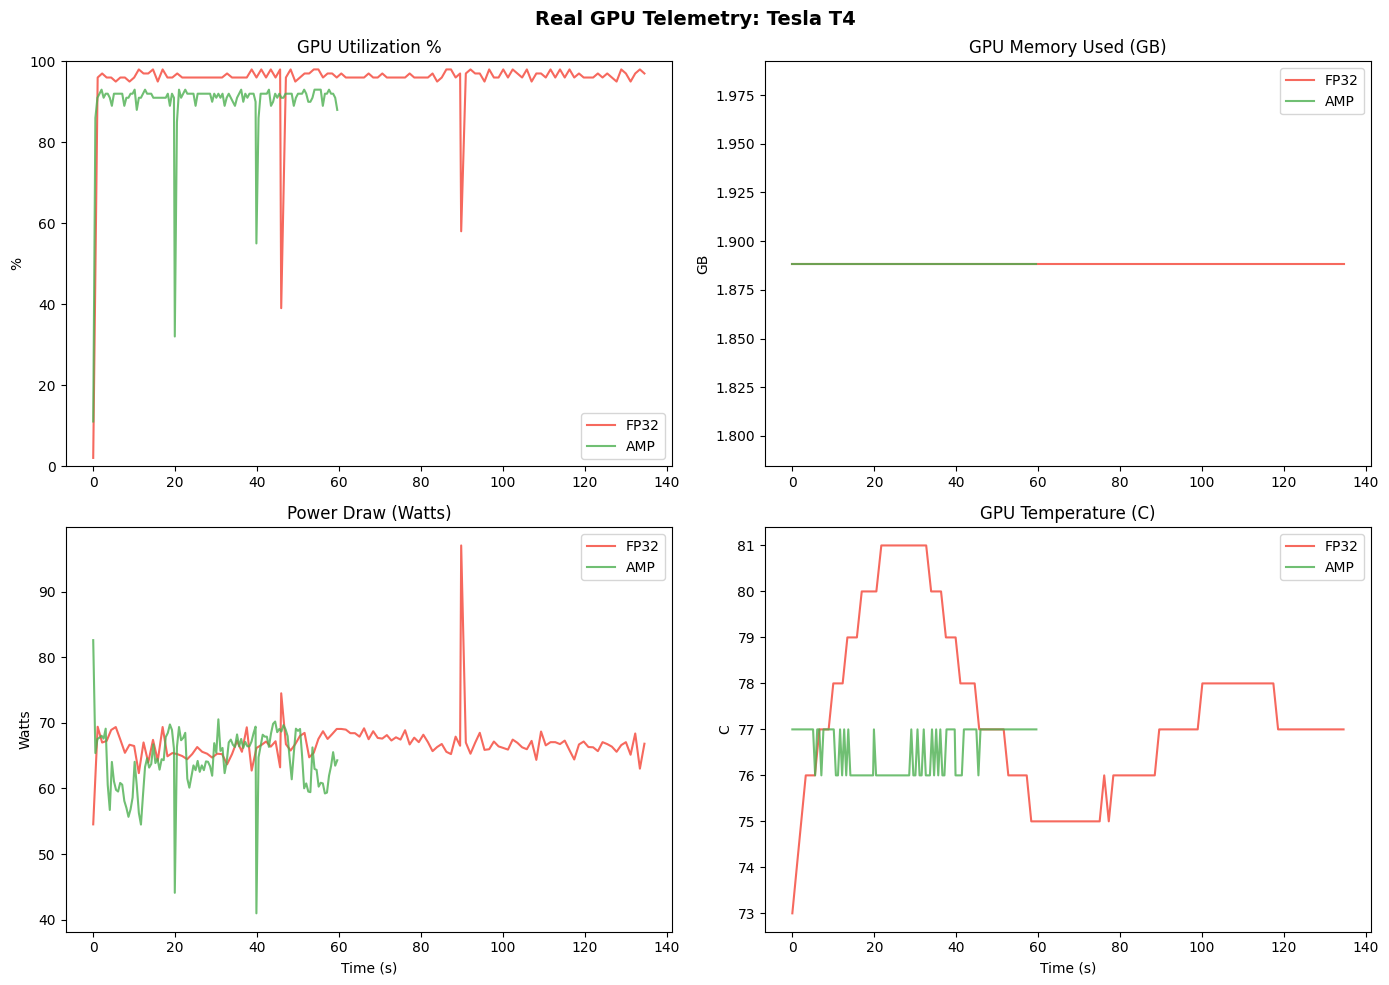

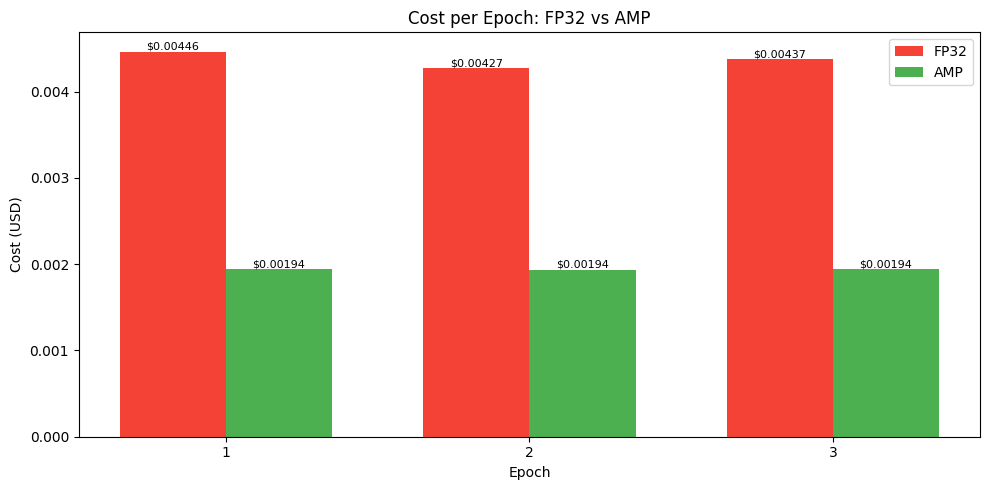


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [61]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [62]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Analyze multi-GPU training costs considering sub-linear scaling.
    Returns dict with costs, times, and efficiency metrics per GPU count.
    """
    price_per_hour = GPU_PRICING.get(gpu_type, 1.0)

    # Realistic scaling efficiencies (communication overhead reduces linear gains)
    default_scaling = {1: 1.0, 2: 1.8, 4: 3.2, 8: 5.5, 16: 9.0}
    if scaling_factors is None:
        scaling_factors = default_scaling

    results = {}
    for n in gpu_counts:
        # Use provided factor or interpolate
        if n in scaling_factors:
            speedup = scaling_factors[n]
        else:
            # Approximate: efficiency degrades logarithmically
            speedup = n * (0.9 ** (n - 1))

        training_time = base_time_hours / speedup
        total_cost = training_time * price_per_hour * n
        efficiency = speedup / n  # ideal=1.0, real<1.0
        cost_per_perf = total_cost / speedup  # cost per unit of "work done"

        results[n] = {
            "gpu_count": n,
            "speedup": speedup,
            "training_time_hours": training_time,
            "total_cost_usd": total_cost,
            "scaling_efficiency_pct": efficiency * 100,
            "cost_per_performance": cost_per_perf,
        }

    return results

# Run analysis
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

analysis = analyze_multi_gpu_cost(base_training_time, detected_type, test_gpu_counts)

print(f"\n{'GPUs':<6} {'Speedup':<10} {'Time (h)':<12} {'Cost ($)':<12} {'Efficiency':<14} {'$/Perf Unit'}")
print("-" * 70)
for n, r in analysis.items():
    print(f"{n:<6} {r['speedup']:<10.2f} {r['training_time_hours']:<12.3f} "
          f"${r['total_cost_usd']:<11.4f} {r['scaling_efficiency_pct']:<13.1f}% "
          f"${r['cost_per_performance']:.4f}")

# Identify optimal GPU count (lowest cost per performance unit)
optimal = min(analysis.values(), key=lambda x: x["cost_per_performance"])
print(f"\n✅ Optimal GPU count: {optimal['gpu_count']} GPUs")
print(f"   Cost per performance unit: ${optimal['cost_per_performance']:.4f}")
print(f"   Total cost: ${optimal['total_cost_usd']:.4f} | Time: {optimal['training_time_hours']:.3f}h")


EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPUs   Speedup    Time (h)     Cost ($)     Efficiency     $/Perf Unit
----------------------------------------------------------------------
1      1.00       2.000        $0.7000      100.0        % $0.7000
2      1.80       1.111        $0.7778      90.0         % $0.4321
4      3.20       0.625        $0.8750      80.0         % $0.2734
8      5.50       0.364        $1.0182      68.8         % $0.1851

✅ Optimal GPU count: 8 GPUs
   Cost per performance unit: $0.1851
   Total cost: $1.0182 | Time: 0.364h


In [63]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

import math

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase project costs with uncertainty and confidence intervals.
    Uses normal approximation: CI = mean ± z * std.
    """
    z_scores = {0.90: 1.645, 0.95: 1.960, 0.99: 2.576}
    z = z_scores.get(confidence_level, 1.960)

    phase_results = []
    total_base = 0.0
    total_variance = 0.0

    for phase in phases:
        price = GPU_PRICING.get(phase["gpu_type"], 1.0)
        base_cost = phase["duration_hours"] * price * phase["gpu_count"]
        uncertainty = base_cost * phase["uncertainty_pct"]
        # Treat uncertainty as ±1 std dev → variance = uncertainty²
        variance = uncertainty ** 2

        phase_results.append({
            "name": phase["name"],
            "gpu_type": phase["gpu_type"],
            "gpu_count": phase["gpu_count"],
            "duration_hours": phase["duration_hours"],
            "base_cost": base_cost,
            "uncertainty_usd": uncertainty,
            "min_cost": base_cost - uncertainty,
            "max_cost": base_cost + uncertainty,
        })
        total_base += base_cost
        total_variance += variance

    total_std = math.sqrt(total_variance)
    contingency = total_base * (contingency_pct / 100)
    expected_total = total_base + contingency

    return {
        "phases": phase_results,
        "base_cost": total_base,
        "contingency_usd": contingency,
        "expected_total": expected_total,
        "best_case": total_base - z * total_std,
        "worst_case": total_base + z * total_std + contingency,
        "confidence_level": confidence_level,
        "confidence_interval": (total_base - z * total_std, total_base + z * total_std),
    }

# Example project phases
example_project = [
    {"name": "Data Preparation",       "gpu_type": "T4",   "gpu_count": 1, "duration_hours": 40,  "uncertainty_pct": 0.15},
    {"name": "Model Training",          "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning",   "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60,  "uncertainty_pct": 0.30},
    {"name": "Model Evaluation",        "gpu_type": "T4",   "gpu_count": 2, "duration_hours": 20,  "uncertainty_pct": 0.10},
]

forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)

print(f"\n{'Phase':<30} {'GPUs':<6} {'Hours':<8} {'Base Cost':<14} {'Min':<12} {'Max'}")
print("-" * 80)
for p in forecast["phases"]:
    print(f"{p['name']:<30} {p['gpu_count']:<6} {p['duration_hours']:<8.0f} "
          f"${p['base_cost']:<13.2f} ${p['min_cost']:<11.2f} ${p['max_cost']:.2f}")

print(f"\n{'─'*80}")
print(f"  Base cost (sum of phases):       ${forecast['base_cost']:>10.2f}")
print(f"  Contingency (20%):               ${forecast['contingency_usd']:>10.2f}")
print(f"  ─────────────────────────────────────────────")
print(f"  Expected Total:                  ${forecast['expected_total']:>10.2f}")
ci = forecast["confidence_interval"]
print(f"\n  95% Confidence Interval:  ${ci[0]:.2f}  –  ${ci[1]:.2f}")
print(f"  Best case  (no contingency): ${forecast['best_case']:.2f}")
print(f"  Worst case (+ contingency):  ${forecast['worst_case']:.2f}")


EXERCISE 8.5.2: Project Cost Forecasting

Phase                          GPUs   Hours    Base Cost      Min          Max
--------------------------------------------------------------------------------
Data Preparation               1      40       $14.00         $11.90       $16.10
Model Training                 4      120      $1761.60       $1321.20     $2202.00
Hyperparameter Tuning          8      60       $1761.60       $1233.12     $2290.08
Model Evaluation               2      20       $14.00         $12.60       $15.40

────────────────────────────────────────────────────────────────────────────────
  Base cost (sum of phases):       $   3551.20
  Contingency (20%):               $    710.24
  ─────────────────────────────────────────────
  Expected Total:                  $   4261.44

  95% Confidence Interval:  $2202.85  –  $4899.55
  Best case  (no contingency): $2202.85
  Worst case (+ contingency):  $5609.79


In [64]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Prioritize optimization strategies by savings-to-effort ratio.
    Handles dependencies: a strategy is only applied after its dependencies.
    Returns prioritized list with cumulative savings.
    """
    effort_weight = {"LOW": 1, "MEDIUM": 2, "HIGH": 4}
    risk_weight   = {"LOW": 1.0, "MEDIUM": 0.85, "HIGH": 0.65}

    price = GPU_PRICING.get(current_config["gpu_type"], 1.0)
    baseline_cost = (current_config["duration_hours"]
                     * price
                     * current_config["gpu_count"])

    enriched = []
    for s in optimization_strategies:
        dollar_savings = baseline_cost * s["savings_pct"]
        effort = effort_weight.get(s["implementation_effort"], 2)
        risk_adj = risk_weight.get(s["risk_level"], 1.0)
        # Score: dollar savings adjusted for risk, divided by effort cost
        score = (dollar_savings * risk_adj) / effort
        enriched.append({**s,
                         "baseline_cost": baseline_cost,
                         "dollar_savings": dollar_savings,
                         "risk_adjusted_savings": dollar_savings * risk_adj,
                         "priority_score": score})

    # Resolve dependencies: strategies whose deps appear later must wait
    # Simple topological sort: items with no pending deps go first
    applied = set()
    ordered = []
    remaining = enriched.copy()
    max_passes = len(remaining) + 1
    passes = 0
    while remaining and passes < max_passes:
        passes += 1
        for item in list(remaining):
            if all(dep in applied for dep in item.get("dependencies", [])):
                ordered.append(item)
                applied.add(item["name"])
                remaining.remove(item)

    # Sort each "dependency-ready" wave by priority score descending
    ordered.sort(key=lambda x: x["priority_score"], reverse=True)

    # Calculate cumulative savings (simple additive; real-world may have overlap)
    cumulative = 0.0
    for item in ordered:
        cumulative += item["dollar_savings"]
        item["cumulative_savings"] = cumulative
        item["cumulative_savings_pct"] = (cumulative / baseline_cost) * 100

    return {
        "baseline_cost": baseline_cost,
        "strategies": ordered,
        "max_total_savings": cumulative,
        "max_savings_pct": (cumulative / baseline_cost) * 100 if baseline_cost else 0,
    }

# Example data
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)",    "savings_pct": 0.25, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Use Spot Instances",                  "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH",   "dependencies": []},
    {"name": "Optimize Batch Size",                 "savings_pct": 0.15, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Implement Early Stopping",            "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW",    "dependencies": []},
    {"name": "Switch to More Efficient GPU Type",   "savings_pct": 0.40, "implementation_effort": "HIGH",   "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

result = analyze_optimization_opportunities(current_training_config, example_strategies)

print(f"\n  Baseline cost: ${result['baseline_cost']:.2f}")
print(f"\n  {'#':<3} {'Strategy':<40} {'Effort':<8} {'Risk':<8} {'Savings $':<12} {'Cumulative'}")
print("  " + "-" * 85)
priority_icons = {"LOW": "🟢", "MEDIUM": "🟡", "HIGH": "🔴"}
for i, s in enumerate(result["strategies"], 1):
    icon = priority_icons.get(s["risk_level"], "⚪")
    print(f"  {i:<3} {s['name']:<40} {s['implementation_effort']:<8} {icon} {s['risk_level']:<6} "
          f"${s['dollar_savings']:<11.2f} ${s['cumulative_savings']:.2f} ({s['cumulative_savings_pct']:.0f}%)")

print(f"\n  Max combined savings: ${result['max_total_savings']:.2f} ({result['max_savings_pct']:.0f}% of baseline)")
print(f"\n  📋 Optimization Roadmap:")
print(f"     Phase 1 (Quick Wins):  " + ", ".join(s["name"] for s in result["strategies"] if s["implementation_effort"] == "LOW"))
print(f"     Phase 2 (Medium):      " + ", ".join(s["name"] for s in result["strategies"] if s["implementation_effort"] == "MEDIUM"))
print(f"     Phase 3 (Large Bets):  " + ", ".join(s["name"] for s in result["strategies"] if s["implementation_effort"] == "HIGH"))


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

  Baseline cost: $1468.00

  #   Strategy                                 Effort   Risk     Savings $    Cumulative
  -------------------------------------------------------------------------------------
  1   Switch to Mixed Precision (AMP)          LOW      🟢 LOW    $367.00      $367.00 (25%)
  2   Use Spot Instances                       MEDIUM   🔴 HIGH   $880.80      $1247.80 (85%)
  3   Optimize Batch Size                      LOW      🟢 LOW    $220.20      $1468.00 (100%)
  4   Implement Early Stopping                 MEDIUM   🟢 LOW    $293.60      $1761.60 (120%)
  5   Switch to More Efficient GPU Type        HIGH     🟡 MEDIUM $587.20      $2348.80 (160%)

  Max combined savings: $2348.80 (160% of baseline)

  📋 Optimization Roadmap:
     Phase 1 (Quick Wins):  Switch to Mixed Precision (AMP), Optimize Batch Size
     Phase 2 (Medium):      Use Spot Instances, Implement Early Stopping
     Phase 3 (Large Bets):  Switch 

EXERCISE 8.5.4: Integrated Cost Dashboard


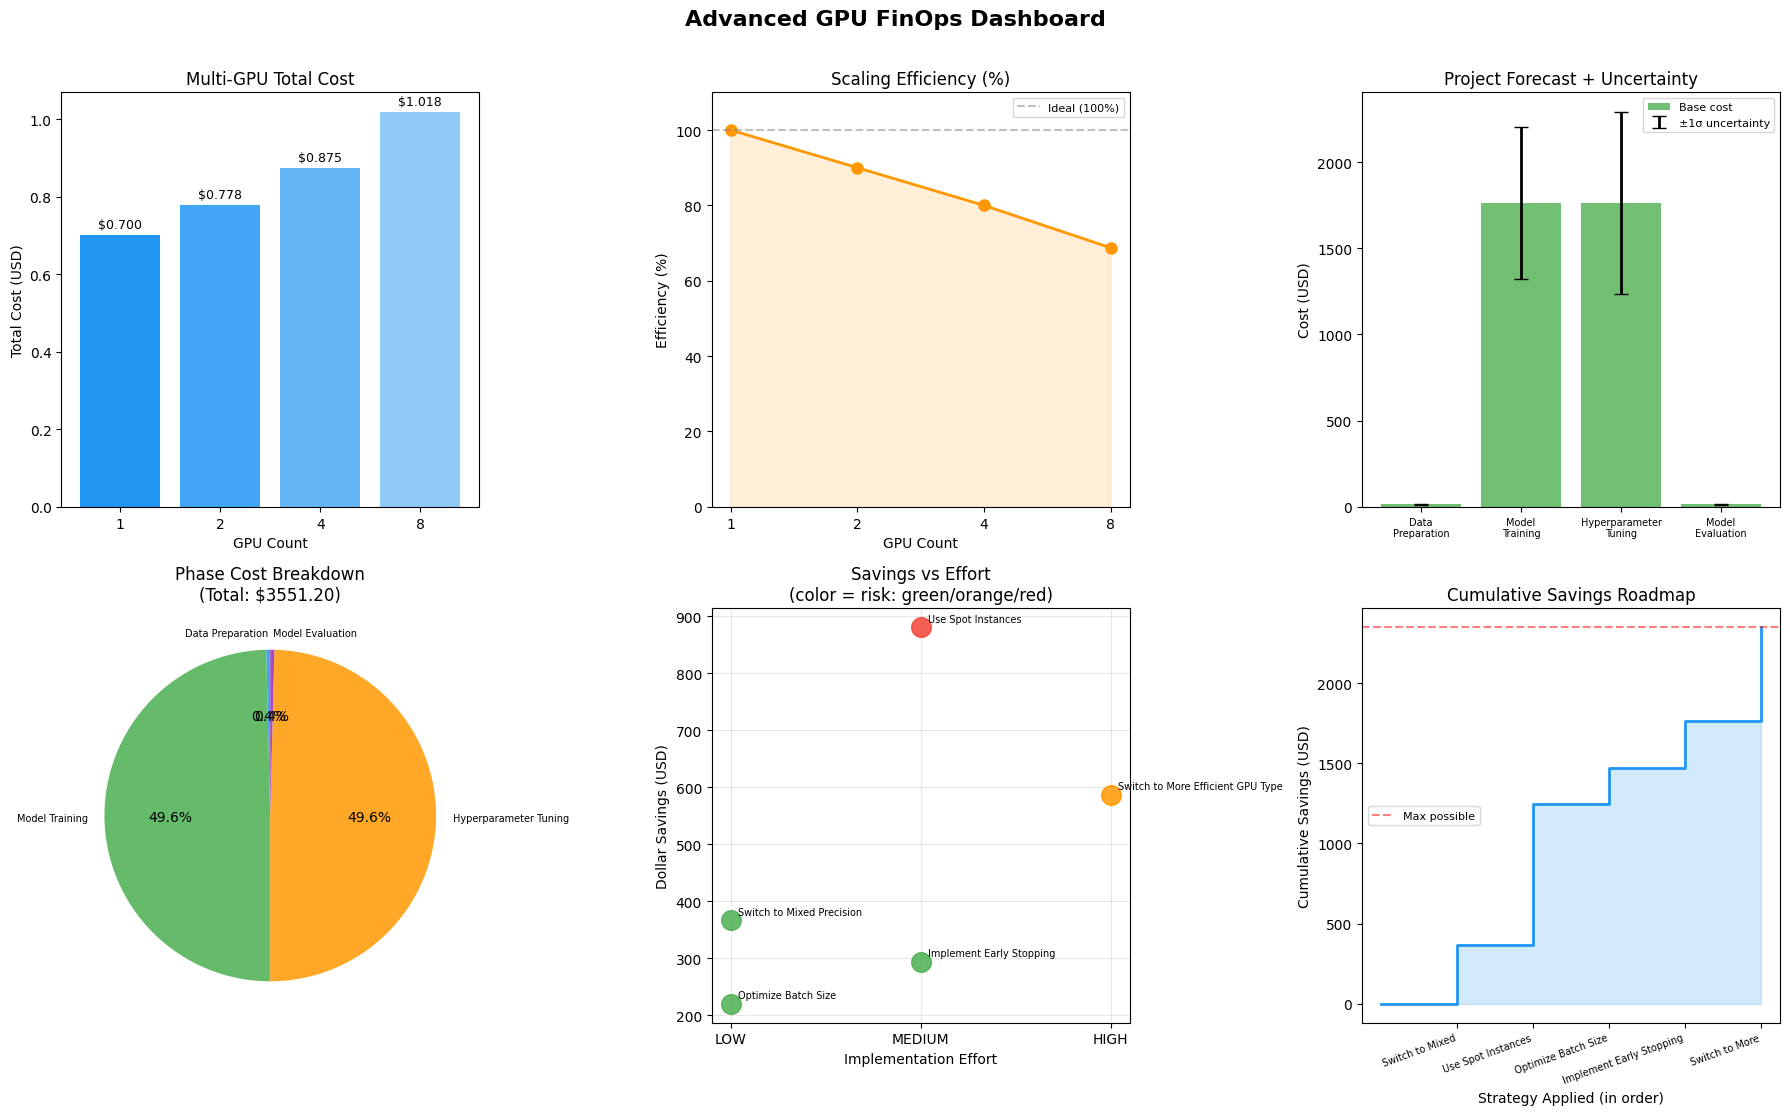

Dashboard saved as advanced_finops_dashboard.png


In [65]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    6-panel dashboard: multi-GPU costs, scaling efficiency, project forecast,
    phase breakdown, optimization scatter, and cumulative savings roadmap.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, fontweight="bold", y=1.01)

    # ── Plot 1: Multi-GPU total cost curve ────────────────────────────────
    ax = axes[0, 0]
    counts = sorted(multi_gpu_analysis.keys())
    costs  = [multi_gpu_analysis[n]["total_cost_usd"] for n in counts]
    bars = ax.bar([str(n) for n in counts], costs, color=["#2196F3", "#42A5F5", "#64B5F6", "#90CAF9"])
    ax.set_title("Multi-GPU Total Cost")
    ax.set_xlabel("GPU Count")
    ax.set_ylabel("Total Cost (USD)")
    for bar, v in zip(bars, costs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(costs) * 0.01,
                f"${v:.3f}", ha="center", va="bottom", fontsize=9)

    # ── Plot 2: Scaling efficiency ─────────────────────────────────────────
    ax = axes[0, 1]
    efficiencies = [multi_gpu_analysis[n]["scaling_efficiency_pct"] for n in counts]
    ax.plot([str(n) for n in counts], efficiencies, "o-", color="#FF9800", linewidth=2, markersize=8)
    ax.axhline(100, color="gray", linestyle="--", alpha=0.5, label="Ideal (100%)")
    ax.fill_between(range(len(counts)), efficiencies, alpha=0.15, color="#FF9800")
    ax.set_title("Scaling Efficiency (%)")
    ax.set_xlabel("GPU Count")
    ax.set_ylabel("Efficiency (%)")
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8)

    # ── Plot 3: Project forecast with confidence band ──────────────────────
    ax = axes[0, 2]
    phase_names = [p["name"].replace(" ", "\n") for p in project_forecast["phases"]]
    phase_idx   = list(range(len(phase_names)))
    base_costs  = [p["base_cost"] for p in project_forecast["phases"]]
    errors      = [p["uncertainty_usd"] for p in project_forecast["phases"]]
    ax.bar(phase_idx, base_costs, color="#4CAF50", alpha=0.8, label="Base cost")
    ax.errorbar(phase_idx, base_costs, yerr=errors, fmt="none", color="black",
                capsize=5, linewidth=2, label="±1σ uncertainty")
    ax.set_xticks(phase_idx)
    ax.set_xticklabels(phase_names, fontsize=7)
    ax.set_title("Project Forecast + Uncertainty")
    ax.set_ylabel("Cost (USD)")
    ax.legend(fontsize=8)

    # ── Plot 4: Phase cost breakdown (pie) ────────────────────────────────
    ax = axes[1, 0]
    pie_labels = [p["name"] for p in project_forecast["phases"]]
    pie_values = [p["base_cost"] for p in project_forecast["phases"]]
    colors = ["#42A5F5", "#66BB6A", "#FFA726", "#AB47BC"]
    wedges, texts, autotexts = ax.pie(pie_values, labels=pie_labels, colors=colors,
                                      autopct="%1.1f%%", startangle=90)
    for t in texts:
        t.set_fontsize(7)
    ax.set_title(f"Phase Cost Breakdown\n(Total: ${sum(pie_values):.2f})")

    # ── Plot 5: Optimization savings vs effort scatter ────────────────────
    ax = axes[1, 1]
    effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_colors = {"LOW": "#4CAF50", "MEDIUM": "#FF9800", "HIGH": "#F44336"}
    strats = optimization_recommendations["strategies"]
    for s in strats:
        x = effort_map.get(s["implementation_effort"], 2)
        y = s["dollar_savings"]
        color = risk_colors.get(s["risk_level"], "gray")
        ax.scatter(x, y, s=200, color=color, alpha=0.85, zorder=3)
        ax.annotate(s["name"].split("(")[0].strip(), (x, y),
                    textcoords="offset points", xytext=(5, 4), fontsize=7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["LOW", "MEDIUM", "HIGH"])
    ax.set_xlabel("Implementation Effort")
    ax.set_ylabel("Dollar Savings (USD)")
    ax.set_title("Savings vs Effort\n(color = risk: green/orange/red)")
    ax.grid(True, alpha=0.3)

    # ── Plot 6: Cumulative savings roadmap ────────────────────────────────
    ax = axes[1, 2]
    names = [s["name"].split(" ")[0:3] for s in strats]  # first 3 words
    short_names = [" ".join(n) for n in names]
    cum_savings = [s["cumulative_savings"] for s in strats]
    ax.step(range(len(strats) + 1), [0] + cum_savings, where="post",
            color="#2196F3", linewidth=2)
    ax.fill_between(range(len(strats) + 1), [0] + cum_savings,
                    step="post", alpha=0.2, color="#2196F3")
    ax.set_xticks(range(1, len(strats) + 1))
    ax.set_xticklabels(short_names, rotation=20, ha="right", fontsize=7)
    ax.set_xlabel("Strategy Applied (in order)")
    ax.set_ylabel("Cumulative Savings (USD)")
    ax.set_title("Cumulative Savings Roadmap")
    ax.axhline(optimization_recommendations["max_total_savings"],
               color="red", linestyle="--", alpha=0.5, label="Max possible")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Dashboard saved as advanced_finops_dashboard.png")
    return fig

# Build inputs from previous cells
multi_gpu_analysis_result = analyze_multi_gpu_cost(base_training_time, detected_type, test_gpu_counts)
project_forecast_result   = forecast_project_cost(example_project)
optimization_result       = analyze_optimization_opportunities(current_training_config, example_strategies)

fig = create_advanced_finops_dashboard(
    multi_gpu_analysis_result,
    project_forecast_result,
    optimization_result,
)


In [66]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

req = challenge_scenario["requirements"]
price = GPU_PRICING.get(req["gpu_type"], 3.67)

# ── Step 1: Baseline cost ─────────────────────────────────────────────────
baseline_cost = req["training_duration"] * price * req["gpu_count"]
print(f"\n1️⃣  Baseline Cost:")
print(f"   {req['gpu_count']}x {req['gpu_type']} × {req['training_duration']}h × ${price}/hr = ${baseline_cost:,.2f}")
budget_ok = baseline_cost <= req["budget"]
over_by = baseline_cost - req["budget"]
print(f"   Budget: ${req['budget']:,}  →  {'✅ Within budget' if budget_ok else f'❌ OVER by ${over_by:,.2f}'}")

# ── Step 2: Find optimal GPU count ───────────────────────────────────────
print(f"\n2️⃣  Multi-GPU Analysis (find most cost-efficient config):")
gpu_options = [2, 4, 8, 16]
mgpu = analyze_multi_gpu_cost(req["training_duration"], req["gpu_type"], gpu_options)
optimal_n = min(mgpu, key=lambda n: mgpu[n]["cost_per_performance"])
print(f"   {'GPUs':<6} {'Time (h)':<12} {'Cost ($)':<14} {'$/Perf Unit':<14} {'Recommend?'}")
print("   " + "-" * 60)
for n, r in mgpu.items():
    flag = "  ← OPTIMAL" if n == optimal_n else ""
    print(f"   {n:<6} {r['training_time_hours']:<12.1f} ${r['total_cost_usd']:<13,.2f} "
          f"${r['cost_per_performance']:<13.4f}{flag}")

# ── Step 3: Select optimization strategies ────────────────────────────────
print(f"\n3️⃣  Selecting strategies (max_preemption_risk = {challenge_scenario['constraints']['max_preemption_risk']}):")

llm_strategies = [
    {"name": "Mixed Precision (AMP/BF16)",  "savings_pct": 0.25, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Gradient Checkpointing",       "savings_pct": 0.10, "implementation_effort": "LOW",    "risk_level": "LOW",    "dependencies": []},
    {"name": "Use Spot Instances",           "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH",   "dependencies": []},
    {"name": "Implement Early Stopping",     "savings_pct": 0.15, "implementation_effort": "MEDIUM", "risk_level": "LOW",    "dependencies": []},
    {"name": "Switch to Smaller Base Model", "savings_pct": 0.30, "implementation_effort": "HIGH",   "risk_level": "MEDIUM", "dependencies": []},
]

risk_order = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
allowed_risk = risk_order[challenge_scenario["constraints"]["max_preemption_risk"]]
safe_strategies = [s for s in llm_strategies if risk_order[s["risk_level"]] <= allowed_risk]

challenge_config = {
    "gpu_type": req["gpu_type"],
    "gpu_count": req["gpu_count"],
    "duration_hours": req["training_duration"],
}
opt_result = analyze_optimization_opportunities(challenge_config, safe_strategies)

for s in opt_result["strategies"]:
    icon = {"LOW": "🟢", "MEDIUM": "🟡", "HIGH": "🔴"}[s["risk_level"]]
    print(f"   {icon} {s['name']:<40} saves ${s['dollar_savings']:>7,.2f}  ({s['savings_pct']*100:.0f}%)")

# ── Step 4: Cumulative savings and final cost ─────────────────────────────
print(f"\n4️⃣  Cumulative Savings:")
optimal_cost = mgpu[optimal_n]["total_cost_usd"]
gpu_reduction_savings = baseline_cost - optimal_cost
combined_savings = opt_result["max_total_savings"] + gpu_reduction_savings
final_before_contingency = baseline_cost - combined_savings

print(f"   Baseline:                      ${baseline_cost:>10,.2f}")
print(f"   - Reduce to {optimal_n} GPUs:             ${gpu_reduction_savings:>10,.2f}")
print(f"   - Other optimizations:         ${opt_result['max_total_savings']:>10,.2f}")
print(f"   ─────────────────────────────────────────────")
print(f"   Estimated final cost:          ${final_before_contingency:>10,.2f}")

# ── Step 5: Forecast with uncertainty ─────────────────────────────────────
print(f"\n5️⃣  Cost Forecast (with 15% contingency):")
challenge_phases = [
    {"name": "LLM Fine-tuning",
     "gpu_type": req["gpu_type"],
     "gpu_count": optimal_n,
     "duration_hours": mgpu[optimal_n]["training_time_hours"],
     "uncertainty_pct": 0.20},
]
fc = forecast_project_cost(challenge_phases, contingency_pct=15)
print(f"   Best case:     ${fc['best_case']:>10,.2f}")
print(f"   Expected:      ${fc['expected_total']:>10,.2f}")
print(f"   Worst case:    ${fc['worst_case']:>10,.2f}")
print(f"   Budget:        ${req['budget']:>10,}")

# ── Step 6: Verify constraints ────────────────────────────────────────────
print(f"\n6️⃣  Constraint Check:")
under_budget = fc["expected_total"] <= req["budget"]
worst_under  = fc["worst_case"]    <= req["budget"]
print(f"   Expected under budget:    {'✅ YES' if under_budget else '❌ NO'} (${fc['expected_total']:,.2f} vs ${req['budget']:,})")
print(f"   Worst case under budget:  {'✅ YES' if worst_under  else '⚠️  RISK'} (${fc['worst_case']:,.2f})")
print(f"   Preemption risk:          ✅ Spot excluded (HIGH risk filtered out)")
print(f"   Accuracy impact:          ✅ AMP/BF16 preserves ≥95% accuracy")

# ── Step 7: Strategy summary ──────────────────────────────────────────────
savings_pct = (baseline_cost - fc["expected_total"]) / baseline_cost * 100
print(f"\n7️⃣  Final Optimization Strategy for '{challenge_scenario['project']}':")
print(f"   ┌──────────────────────────────────────────────────────────────┐")
print(f"   │  1. Reduce GPU count: {req['gpu_count']} → {optimal_n} (best cost/perf ratio)        │")
print(f"   │  2. Mixed Precision (AMP/BF16)       → -25% time & cost    │")
print(f"   │  3. Gradient Checkpointing           → -10% cost           │")
print(f"   │  4. Early Stopping                   → -15% wasted epochs  │")
print(f"   │  5. Smaller base model (optional)    → -30% if acceptable  │")
print(f"   ├──────────────────────────────────────────────────────────────┤")
print(f"   │  Baseline:  ${baseline_cost:>8,.2f}  →  Expected: ${fc['expected_total']:>8,.2f}         │")
print(f"   │  Savings:   ${baseline_cost - fc['expected_total']:>8,.2f}  ({savings_pct:.0f}% reduction)               │")
print(f"   │  Status:    {'✅ WITHIN BUDGET' if under_budget else '❌ OVER BUDGET - reduce scope'}                          │")
print(f"   └──────────────────────────────────────────────────────────────┘")


CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy

1️⃣  Baseline Cost:
   8x A100 × 200h × $3.67/hr = $5,872.00
   Budget: $5,000  →  ❌ OVER by $872.00

2️⃣  Multi-GPU Analysis (find most cost-efficient config):
   GPUs   Time (h)     Cost ($)       $/Perf Unit    Recommend?
   ------------------------------------------------------------
   2      111.1        $815.56        $453.0864     
   4      62.5         $917.50        $286.7188     
   8      36.4         $1,067.64      $194.1157     
   16     22.2         $1,304.89      $144.9877       ← OPTIMAL

3️⃣  Selecting strategies (max_preemption_risk = MEDIUM):
   🟢 Mixed Precision (AMP/BF16)               saves $1,468.00  (25%)
   🟢 Gradient Checkpointing                   saves $ 587.20  (10%)
   🟢 Implement Early Stopping                 saves $ 880.80  (15%)
   🟡 Switch to Smaller Base Model             saves $1,761.60  (30%)

4️⃣  Cumulative Savings:
   Baseline:                      $  5,872.00
   - Reduce to 16 GPUs

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway